## Download data NAB

In [6]:
!git clone https://github.com/numenta/NAB.git
!pip install statsmodels -q

fatal: destination path 'NAB' already exists and is not an empty directory.


⚡️ Tip	Connect GitHub to Studios: https://lightning.ai/vunth22it/home?settings=integrations



# machine_temperature_system_failure

## Phase 1: EDA & Hiểu Data

### Load và plot cơ bản

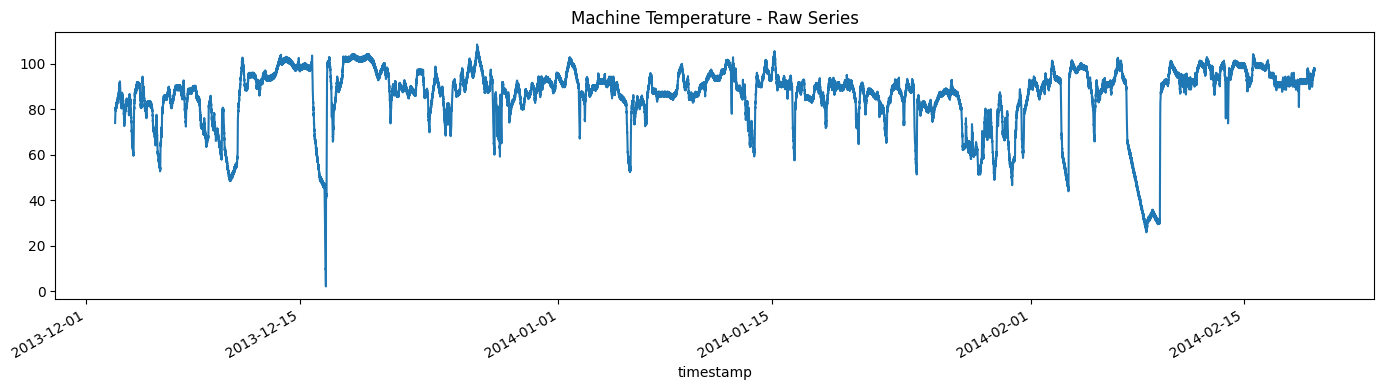

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
df = pd.read_csv('NAB/data/realKnownCause/machine_temperature_system_failure.csv', 
                  parse_dates=['timestamp'])
df = df.set_index('timestamp')
series = df['value']

# Plot raw time series
fig, ax = plt.subplots(figsize=(14, 4))
series.plot(ax=ax, title='Machine Temperature - Raw Series')
plt.tight_layout()
plt.show()

### Tính stats + phân tích distribution

Mean:     85.93
Std:      13.75
Skewness: -1.834
Min/Max:  2.08 / 108.51


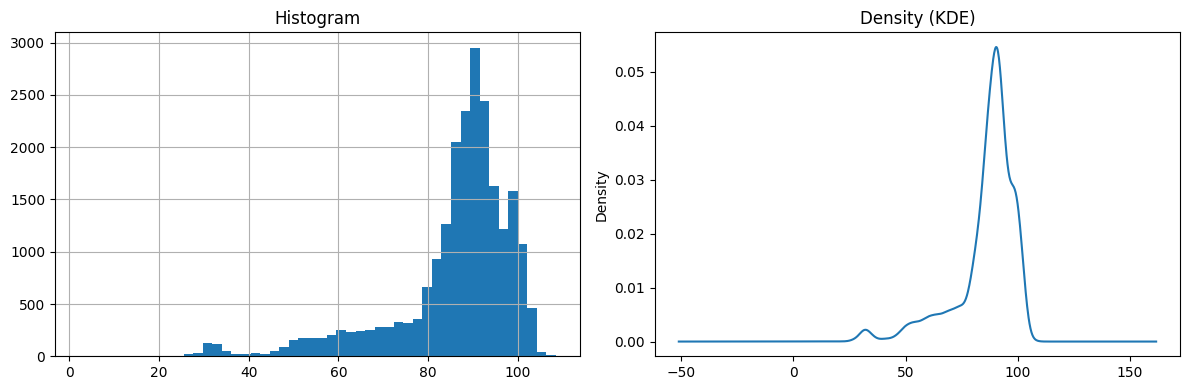

In [7]:
print(f"Mean:     {series.mean():.2f}")
print(f"Std:      {series.std():.2f}")
print(f"Skewness: {stats.skew(series):.3f}")
print(f"Min/Max:  {series.min():.2f} / {series.max():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
series.hist(bins=50, ax=axes[0])
axes[0].set_title('Histogram')
series.plot(kind='kde', ax=axes[1])
axes[1].set_title('Density (KDE)')
plt.tight_layout()

**Đánh giá**

|skewness| = 1.834 > 1 → Data bị skew → dùng IQR hoặc log transform

### Plot ACF

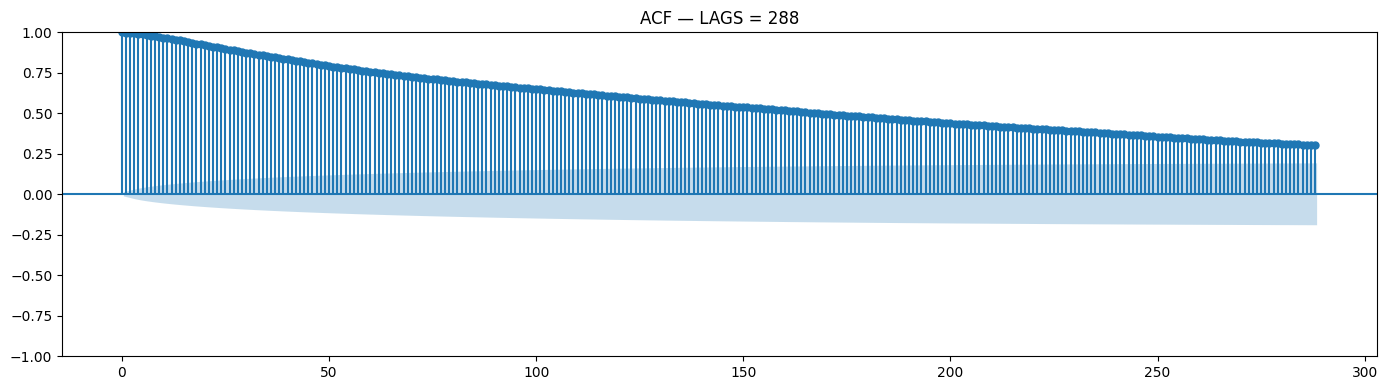

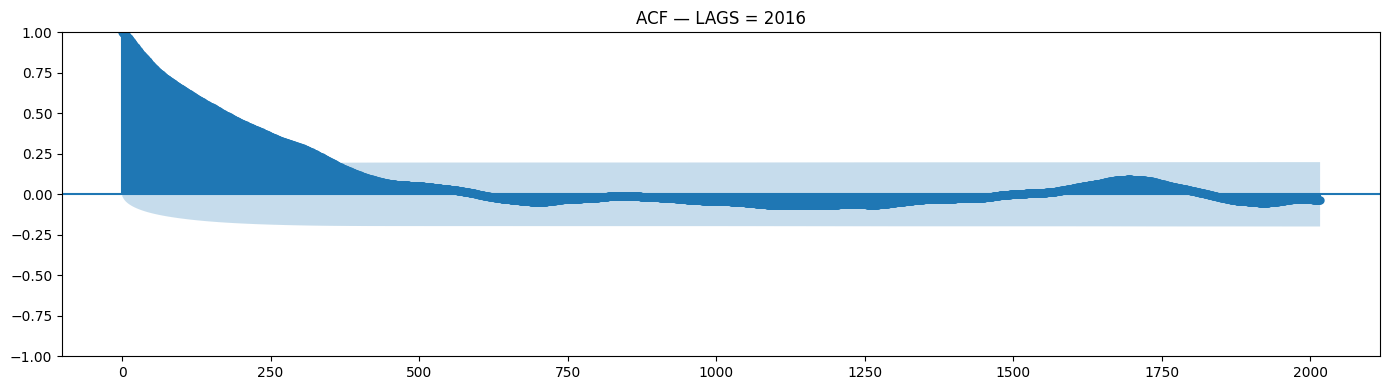

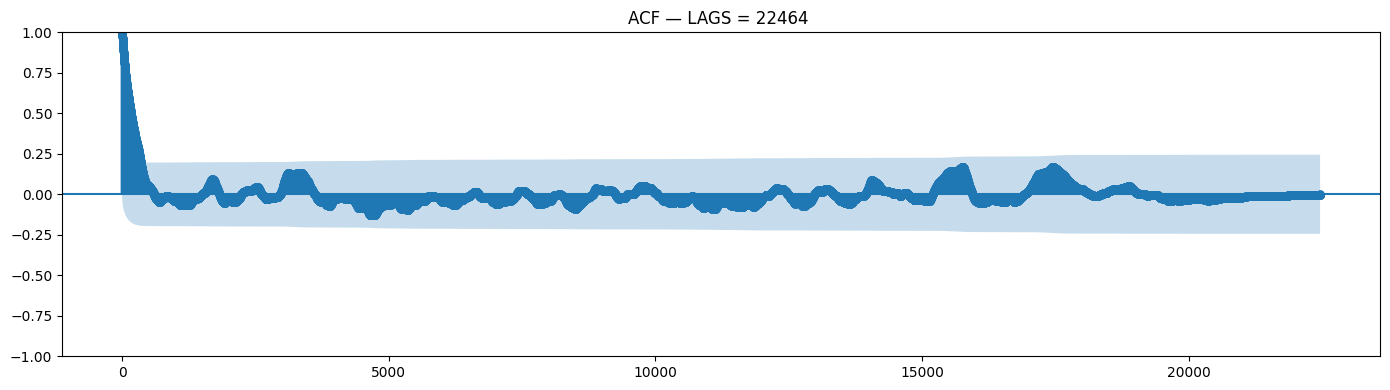

In [8]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(series, lags=288, ax=ax)
ax.set_title('ACF — LAGS = 288')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(series, lags=2016, ax=ax)
ax.set_title('ACF — LAGS = 2016')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(series, lags=22464, ax=ax)
ax.set_title('ACF — LAGS = 22464 ')
plt.tight_layout()
plt.show()

* Panel 1 (lags=288): Giảm đều từ 1.0 → 0.3, không có peak ở lag=288. → Không có daily seasonal pattern rõ ràng.
* Panel 2 (lags=2016): Drops nhanh về ~0 sau lag≈300, sau đó flat trong confidence band. Không có peak ở lag=2016. → Không có weekly seasonal pattern.
* Panel 3 (lags=22464 = toàn bộ data): Sau lag≈300 hoàn toàn flat, các bump nhỏ nằm trong confidence band (vùng xanh nhạt) → noise, không có ý nghĩa thống kê.
  
**Kết luận:**
Data này chỉ có TREND, không có seasonal
- Strong trend (non-stationary): ACF giảm đều, chậm
- NO daily seasonal pattern (không có peak ở lag=288)
- NO weekly seasonal pattern (không có peak ở lag=2016)
- Autocorrelation decay về 0 sau ~300 lag (≈ 25 giờ)


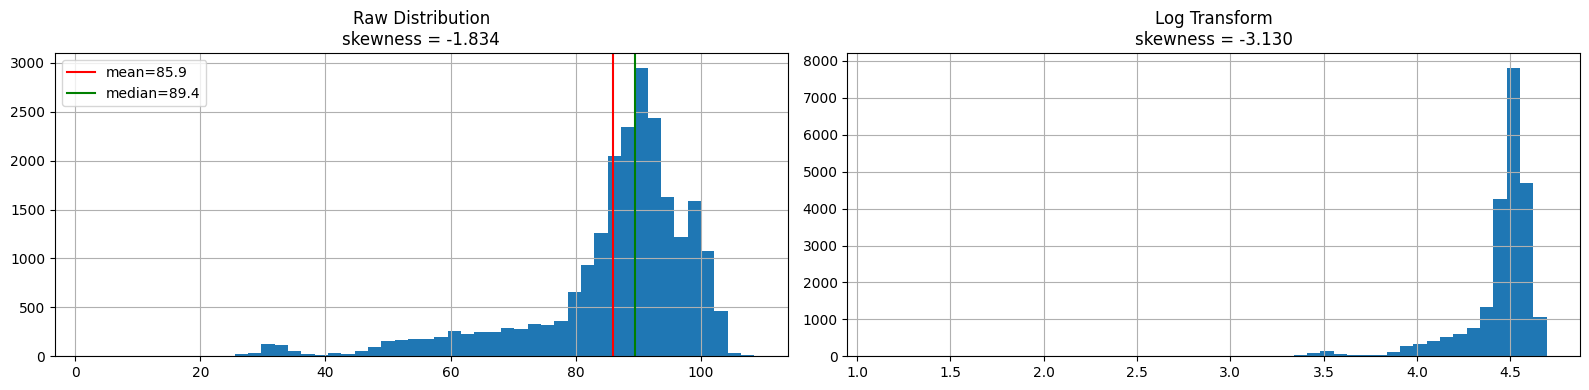

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
skewness = stats.skew(series)
# 1. Histogram raw
series.hist(bins=50, ax=axes[0])
axes[0].set_title(f'Raw Distribution\nskewness = {skewness:.3f}')
axes[0].axvline(series.mean(), color='red', label=f'mean={series.mean():.1f}')
axes[0].axvline(series.median(), color='green', label=f'median={series.median():.1f}')
axes[0].legend()

# 2. Log transform
import numpy as np
log_series = np.log1p(series)
log_series.hist(bins=50, ax=axes[1])
axes[1].set_title(f'Log Transform\nskewness = {stats.skew(log_series):.3f}')

plt.tight_layout()

### EDA Conclusion (Final)

| Property       | Kết quả                                       |
|----------------|-----------------------------------------------|
| Stationary     | KHÔNG — strong trend                          |
| Seasonal       | KHÔNG — không có peak ở lag=288 hay lag=2016  |
| Skewness       | +1.834 → heavily right-skewed                 |
| Log transform  | KHÔNG hiệu quả (overcorrect → -3.130)         |
| Anomaly type   | Spike đột ngột + drift dọc trend              |

**Method choice: Rolling IQR**

Lý do:
1. Skewness=1.834 → KHÔNG dùng 3σ hay EWMA trực tiếp
2. Log transform overcorrect (-3.130) → không dùng
3. IQR dùng median/percentile thay mean/std
   → hoàn toàn không bị ảnh hưởng bởi skew
4. Rolling window=288 → handle được trend

**Detector 1:** Rolling IQR (window=288)
**Detector 2:** Isolation Forest (contamination=0.02)

## Phase 2: Implement 2 Detectors

### Detector 1

In [24]:
anomalies_d1 = detect_ewma(series, alpha=0.05, threshold=0.5)
p1, r1, f1_d1 = evaluate(y_true, anomalies_d1.values, "EWMA (a=0.05, t=0.5)")

[EWMA (a=0.05, t=0.5)]  P=0.217  R=0.699  F1=0.331  FP=12005  FN=1431


In [18]:
import json
with open('NAB/labels/combined_labels.json') as f:
    windows = json.load(f)

key = "realKnownCause/machine_temperature_system_failure.csv"
timestamps = windows[key]
anomaly_windows = list(zip(timestamps[0::2], timestamps[1::2]))

y_true = np.zeros(len(df))
for start, end in anomaly_windows:
    mask = (df.index >= pd.Timestamp(start)) & \
           (df.index <= pd.Timestamp(end))
    y_true[mask] = 1

print(f"✓ Labels loaded: {int(y_true.sum())} anomaly points ({y_true.mean()*100:.1f}%)")

# Tạo y_true
y_true = np.zeros(len(df))
for start, end in anomaly_windows:
    mask = (df.index >= pd.Timestamp(start)) & \
           (df.index <= pd.Timestamp(end))
    y_true[mask] = 1

print(f"\nTotal anomaly points: {int(y_true.sum())} / {len(y_true)}")
print(f"Anomaly rate: {y_true.mean()*100:.2f}%")

✓ Labels loaded: 4754 anomaly points (20.9%)

Total anomaly points: 4754 / 22695
Anomaly rate: 20.95%


In [19]:
def detect_iqr_rolling(series, window=288):
    s = pd.Series(series.values, index=series.index)
    anomalies = pd.Series(False, index=s.index)
    
    for i in range(window, len(s)):
        window_data = s.iloc[i-window:i]
        q1  = np.percentile(window_data, 25)
        q3  = np.percentile(window_data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        anomalies.iloc[i] = (s.iloc[i] < lower) or (s.iloc[i] > upper)
    
    return anomalies

for w in [288, 2576, 1440, 2880]:
    a = detect_iqr_rolling(series, window=w)
    print(f"\nwindow={w} ({w*5//60}h = {w*5//60//24}d):")
    evaluate(y_true, a.values, f"IQR w={w}")


window=288 (24h = 1d):
[IQR w=288]  P=0.258  R=0.129  F1=0.172  FP=1763  FN=4142

window=2576 (214h = 8d):
[IQR w=2576]  P=0.270  R=0.067  F1=0.107  FP=856  FN=4437

window=1440 (120h = 5d):
[IQR w=1440]  P=0.354  R=0.112  F1=0.170  FP=973  FN=4221

window=2880 (240h = 10d):
[IQR w=2880]  P=0.158  R=0.033  F1=0.054  FP=830  FN=4598


In [20]:
def detect_ewma(series, alpha=0.1, threshold=3.0):
    s = pd.Series(series.values, index=series.index)
    ewma     = s.ewm(alpha=alpha, adjust=False).mean()
    ewma_std = s.ewm(alpha=alpha, adjust=False).std()
    ewma_std = ewma_std.replace(0, 1e-10)
    deviation = np.abs(s - ewma) / ewma_std
    return deviation > threshold

print("=== Tuning EWMA threshold ===")
for alpha, thresh in [(0.05, 0.5), (0.05, 1.0), (0.05, 1.5), 
                      (0.1, 0.5),  (0.1, 1.0),  (0.1, 1.5)]:
    a = detect_ewma(series, alpha=alpha, threshold=thresh)
    print(f"\nalpha={alpha}, threshold={thresh}:")
    evaluate(y_true, a.values, f"EWMA a={alpha} t={thresh}")

=== Tuning EWMA threshold ===

alpha=0.05, threshold=0.5:
[EWMA a=0.05 t=0.5]  P=0.217  R=0.699  F1=0.331  FP=12005  FN=1431

alpha=0.05, threshold=1.0:
[EWMA a=0.05 t=1.0]  P=0.207  R=0.323  F1=0.252  FP=5883  FN=3219

alpha=0.05, threshold=1.5:
[EWMA a=0.05 t=1.5]  P=0.190  R=0.086  F1=0.118  FP=1732  FN=4347

alpha=0.1, threshold=0.5:
[EWMA a=0.1 t=0.5]  P=0.211  R=0.679  F1=0.322  FP=12075  FN=1524

alpha=0.1, threshold=1.0:
[EWMA a=0.1 t=1.0]  P=0.208  R=0.315  F1=0.251  FP=5692  FN=3257

alpha=0.1, threshold=1.5:
[EWMA a=0.1 t=1.5]  P=0.221  R=0.069  F1=0.105  FP=1152  FN=4428


## Detector 1 Tuning Log

### Round 1: IQR Rolling (method bị loại)
| window | Precision | Recall | F1    | Lý do fail |
|--------|-----------|--------|-------|------------|
| 288    | 0.258     | 0.129  | 0.172 | window nhỏ, band drift theo anomaly |
| 1440   | 0.354     | 0.112  | 0.170 | sustained shift không phải spike |
| 2576   | 0.270     | 0.067  | 0.107 | window lớn → miss anomaly ngắn |
| 2880   | 0.158     | 0.033  | 0.054 | quá lớn, baseline bị ô nhiễm |
→ Kết luận: IQR không phù hợp — anomaly là sustained shift 5-11 ngày

### Round 2: EWMA threshold=3.0 (quá cao)
| alpha | Recall | Lý do fail |
|-------|--------|------------|
| 0.05  | 0.001  | threshold 3.0 quá cao, EWMA adapt dần → deviation không vượt 3σ |
| 0.1   | 0.000  | same |
| 0.3   | 0.000  | same |

### Round 3: EWMA tune threshold (final)
| alpha | threshold | Precision | Recall | F1    |
|-------|-----------|-----------|--------|-------|
| 0.05  | 0.5       | 0.217     | 0.699  | 0.331 | ← BEST
| 0.05  | 1.0       | 0.207     | 0.323  | 0.252 |
| 0.05  | 1.5       | 0.190     | 0.086  | 0.118 |
| 0.1   | 0.5       | 0.211     | 0.679  | 0.322 |
| 0.1   | 1.0       | 0.208     | 0.315  | 0.251 |
| 0.1   | 1.5       | 0.221     | 0.069  | 0.105 |

→ Best: alpha=0.05, threshold=0.5 → P=0.217, R=0.699, F1=0.331
→ Chọn Recall cao vì AIOps ưu tiên không miss anomaly

### Detector 2 

In [21]:
from sklearn.ensemble import IsolationForest
import os

def build_features(series, window=288):
    s = pd.Series(series.values, index=series.index)
    features = pd.DataFrame({
        'value':            s,
        'rolling_mean':     s.rolling(window).mean(),
        'rolling_std':      s.rolling(window).std(),
        'rolling_mean_4h':  s.rolling(window * 4).mean(),
        'rate_of_change':   s.diff(),
        'rate_of_change_5': s.diff(5),
        'lag_1':            s.shift(1),
        'lag_288':          s.shift(window),
        'z_score':          (s - s.rolling(window).mean()) /
                            s.rolling(window).std().replace(0, 1e-10),
    })
    return features.dropna()

X = build_features(series)
y_true_if = y_true[len(y_true) - len(X):]

print(f"Feature table: {X.shape}")
print(f"Anomaly rate in aligned y_true: {y_true_if.mean()*100:.2f}%")

# Tune contamination quanh anomaly rate thực tế
print("\n=== Tuning Isolation Forest ===")
results_if = {}
for cont in [0.15, 0.20, 0.25]:
    clf = IsolationForest(n_estimators=200, contamination=cont, random_state=42)
    clf.fit(X)
    y_pred = (clf.predict(X) == -1).astype(int)
    print(f"\ncontamination={cont}:")
    p, r, f = evaluate(y_true_if, y_pred, f"IF cont={cont}")
    results_if[cont] = (p, r, f)

Feature table: (21544, 9)
Anomaly rate in aligned y_true: 22.07%

=== Tuning Isolation Forest ===

contamination=0.15:
[IF cont=0.15]  P=0.502  R=0.341  F1=0.406  FP=1611  FN=3133

contamination=0.2:
[IF cont=0.2]  P=0.493  R=0.447  F1=0.469  FP=2184  FN=2629

contamination=0.25:
[IF cont=0.25]  P=0.435  R=0.493  F1=0.462  FP=3043  FN=2411


In [22]:
# Best config
best_cont = 0.20
clf_final = IsolationForest(n_estimators=200, contamination=best_cont, random_state=42)
clf_final.fit(X)
y_pred_if = (clf_final.predict(X) == -1).astype(int)

p2, r2, f2 = evaluate(y_true_if, y_pred_if, f"IF final (cont={best_cont})")

# Save model
import joblib
joblib.dump(clf_final, 'isolation_forest.joblib')
print(f"\nModel saved. Size: {os.path.getsize('isolation_forest.joblib')/1024:.1f} KB")

[IF final (cont=0.2)]  P=0.493  R=0.447  F1=0.469  FP=2184  FN=2629

Model saved. Size: 2193.5 KB


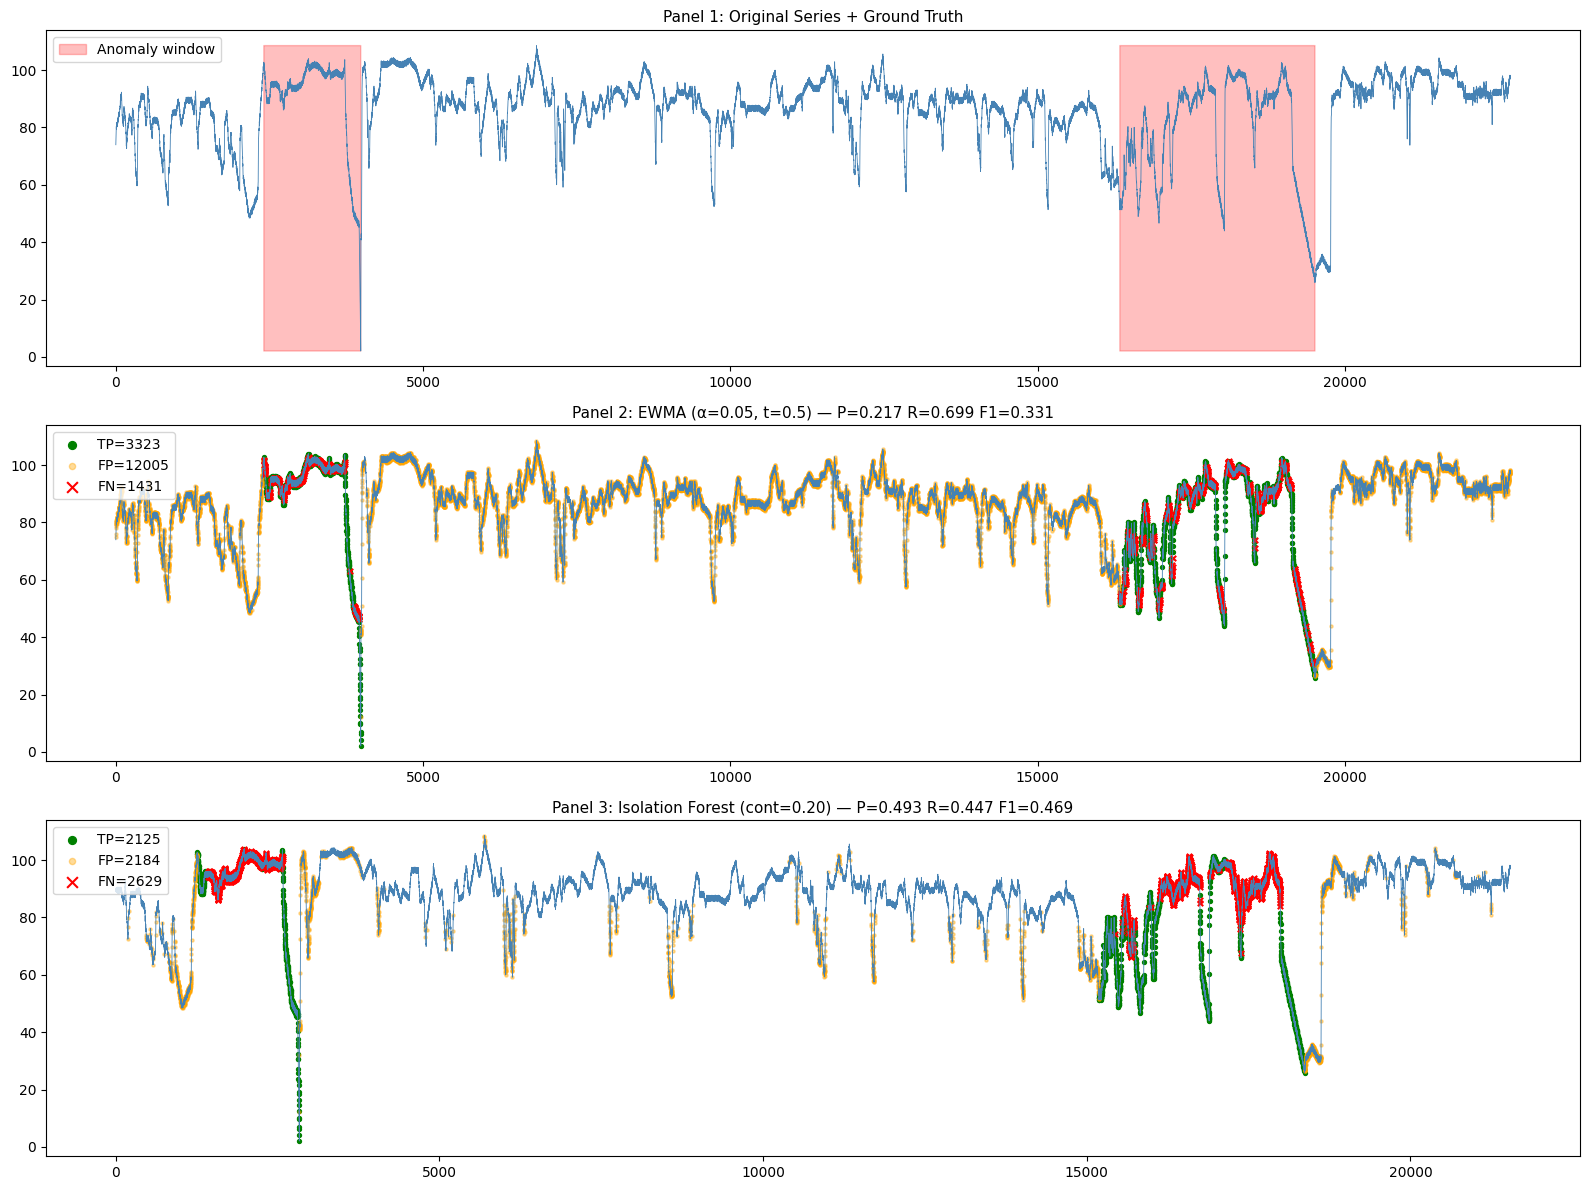

Saved: comparison.png


In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Align indices
series_full = series.values
series_if   = series.values[len(series) - len(X):]
y_true_full = y_true
y_true_if_  = y_true_if

x_full = np.arange(len(series_full))
x_if   = np.arange(len(series_if))

# ── Panel 1: Original + ground truth ──
axes[0].plot(x_full, series_full, lw=0.6, color='steelblue')
axes[0].fill_between(x_full, series_full.min(), series_full.max(),
                     where=y_true_full==1,
                     alpha=0.25, color='red', label='Anomaly window')
axes[0].set_title('Panel 1: Original Series + Ground Truth', fontsize=11)
axes[0].legend(loc='upper left')

# ── Panel 2: EWMA ──
ewma_pred = anomalies_d1.values.astype(int)
tp = np.where((ewma_pred==1) & (y_true_full==1))[0]
fp = np.where((ewma_pred==1) & (y_true_full==0))[0]
fn = np.where((ewma_pred==0) & (y_true_full==1))[0]

axes[1].plot(x_full, series_full, lw=0.6, color='steelblue')
axes[1].scatter(tp, series_full[tp], color='green',  s=8,  label=f'TP={len(tp)}')
axes[1].scatter(fp, series_full[fp], color='orange', s=5,  label=f'FP={len(fp)}', alpha=0.4)
axes[1].scatter(fn, series_full[fn], color='red',    s=15, marker='x', label=f'FN={len(fn)}')
axes[1].set_title(f'Panel 2: EWMA (α=0.05, t=0.5) — P={p1:.3f} R={r1:.3f} F1={f1_d1:.3f}', fontsize=11)
axes[1].legend(loc='upper left', markerscale=2)

# ── Panel 3: Isolation Forest ──
tp_if = np.where((y_pred_if==1) & (y_true_if_==1))[0]
fp_if = np.where((y_pred_if==1) & (y_true_if_==0))[0]
fn_if = np.where((y_pred_if==0) & (y_true_if_==1))[0]

axes[2].plot(x_if, series_if, lw=0.6, color='steelblue')
axes[2].scatter(tp_if, series_if[tp_if], color='green',  s=8,  label=f'TP={len(tp_if)}')
axes[2].scatter(fp_if, series_if[fp_if], color='orange', s=5,  label=f'FP={len(fp_if)}', alpha=0.4)
axes[2].scatter(fn_if, series_if[fn_if], color='red',    s=15, marker='x', label=f'FN={len(fn_if)}')
axes[2].set_title(f'Panel 3: Isolation Forest (cont=0.20) — P={p2:.3f} R={r2:.3f} F1={f2:.3f}', fontsize=11)
axes[2].legend(loc='upper left', markerscale=2)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison.png")

## Phase 3: So Sánh & Reflection

### Bảng so sánh

| Metric       | EWMA (a=0.05, t=0.5) | Isolation Forest (cont=0.20) |
|--------------|----------------------|------------------------------|
| Precision    | 0.217                | 0.493                        |
| Recall       | 0.699                | 0.447                        |
| F1           | 0.331                | 0.469                        |
| False Alarms | 12005                | 2184                         |
| Miss (FN)    | 1431                 | 2629                         |

### Nhận xét từ plot

**EWMA (Panel 2):**
- Recall cao (0.699) — bắt được phần lớn anomaly thật
- FP=12005 quá lớn — threshold=0.5 quá nhạy, trigger ở mọi
  biến động nhỏ kể cả data bình thường
- Đặc biệt FP rải đều index 5000-15000 (vùng hoàn toàn bình thường)
  → on-call sẽ bị alert fatigue, bắt đầu ignore alert

**Isolation Forest (Panel 3):**
- Precision cao hơn gấp đôi (0.493 vs 0.217) → ít false alarm hơn
- Detect tốt spike/drop đột ngột — đúng với thế mạnh của IF
  (isolation path ngắn = anomaly rõ ràng)
- Miss phần giữa anomaly window — vùng data "chỉ hơi bất thường"
  không đủ để IF isolate nhanh → FN cao hơn EWMA

### Trade-off

| | EWMA | Isolation Forest |
|---|---|---|
| Mạnh ở | Recall — không bỏ sót | Precision — ít false alarm |
| Yếu ở | FP quá cao — alert fatigue | FN cao — miss sustained anomaly |
| Phù hợp khi | Cần catch mọi anomaly, chấp nhận noise | Cần alert chất lượng cao |

### Production Choice

**Isolation Forest** phù hợp hơn cho production vì:
1. FP=2184 vs 12005 — on-call nhận 5.5x ít alert hơn
2. F1=0.469 > 0.331 — overall performance tốt hơn
3. Precision=0.493 — gần 1/2 alert là thật, on-call không bị fatigue

Nếu hệ thống critical (không được miss anomaly nào):
→ Dùng EWMA làm first-pass (recall cao), IF làm second-pass filter
→ Pipeline: EWMA alert → IF confirm → page on-call
→ Kết quả: recall cao của EWMA + precision cao của IF

### Lesson learned từ dataset này

1. Anomaly rate 20.95% (rất cao) → contamination phải tune
   theo thực tế, không dùng default 0.01-0.05
2. IQR hoàn toàn fail với sustained shift dài ngày → method
   choice phải dựa trên EDA, không phải chỉ skewness
3. Log transform không phải lúc nào cũng fix skew
   (overcorrect -3.130) → luôn verify sau transform